# Stochastic Calculus for Finance - Assignment 4

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [26]:
# Some Claude slop to make clean matplotlib style
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
BINS = 50
RNG = np.random.default_rng(seed=42)

---
## Section 1 - Sampling Continuous Random Variables

### Exercise 1a - Uniform distribution on $[0, 2\pi]$

We generate $N$ samples uniformly in $[0, 1]$ and transform them to $[0, 2\pi]$ via $z = a + (b−a)y$.
The normalised histogram should approximate the pdf $f(x) = 1/(2\pi)$ on $[0, 2π]$.

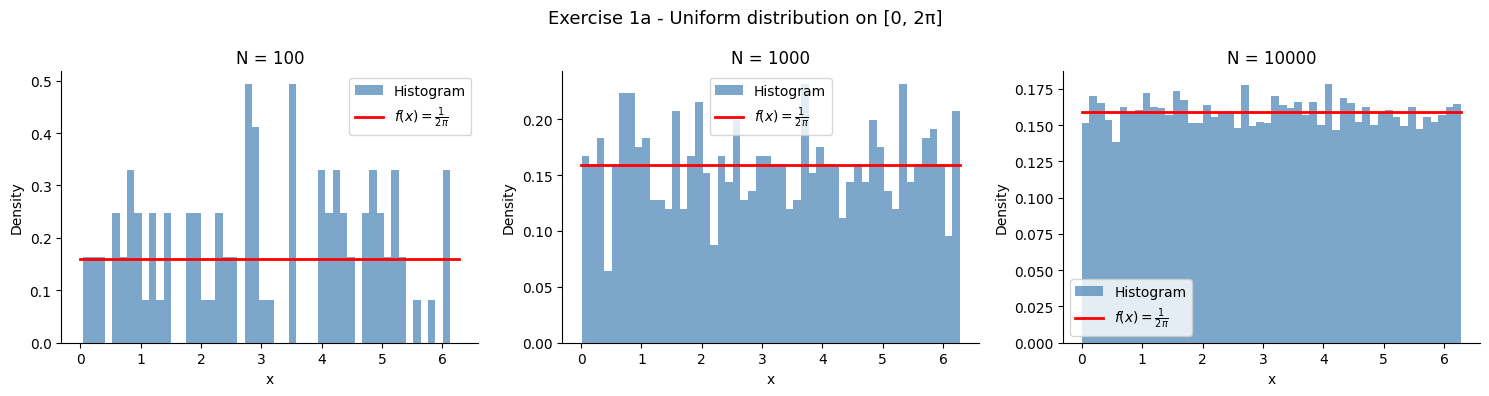

In [27]:
N_values = [100, 1000, 10000]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Exercise 1a - Uniform distribution on [0, 2π]', fontsize=13)

uniform_samples = {}   #Storing for use in Ex 1d

for ax, N in zip(axes, N_values):
    y = RNG.random(N)                     # uniform in [0, 1]
    z = 0 + (2 * np.pi - 0) * y          # Transformation to [0, 2π]
    uniform_samples[N] = z

    ax.hist(z, bins=BINS, density=True, color='steelblue', alpha=0.7, label='Histogram')

    x_vals = np.linspace(0, 2 * np.pi, 300)
    ax.plot(x_vals, np.full_like(x_vals, 1 / (2 * np.pi)), 'r-', lw=2, label=r'$f(x)=\frac{1}{2\pi}$')

    ax.set_title(f'N = {N}')
    ax.set_xlabel('x')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

### Exercise 1b - Exponential distribution

The inverse CDF (ppf) of the exponential distribution is $F⁻¹(y) = −(1/λ) log(1−y)$.

We apply this to uniform samples to obtain exponentially distributed samples and compare
the normalised histogram with the theoretical pdf $f(x) = λ e^{−λx}$.

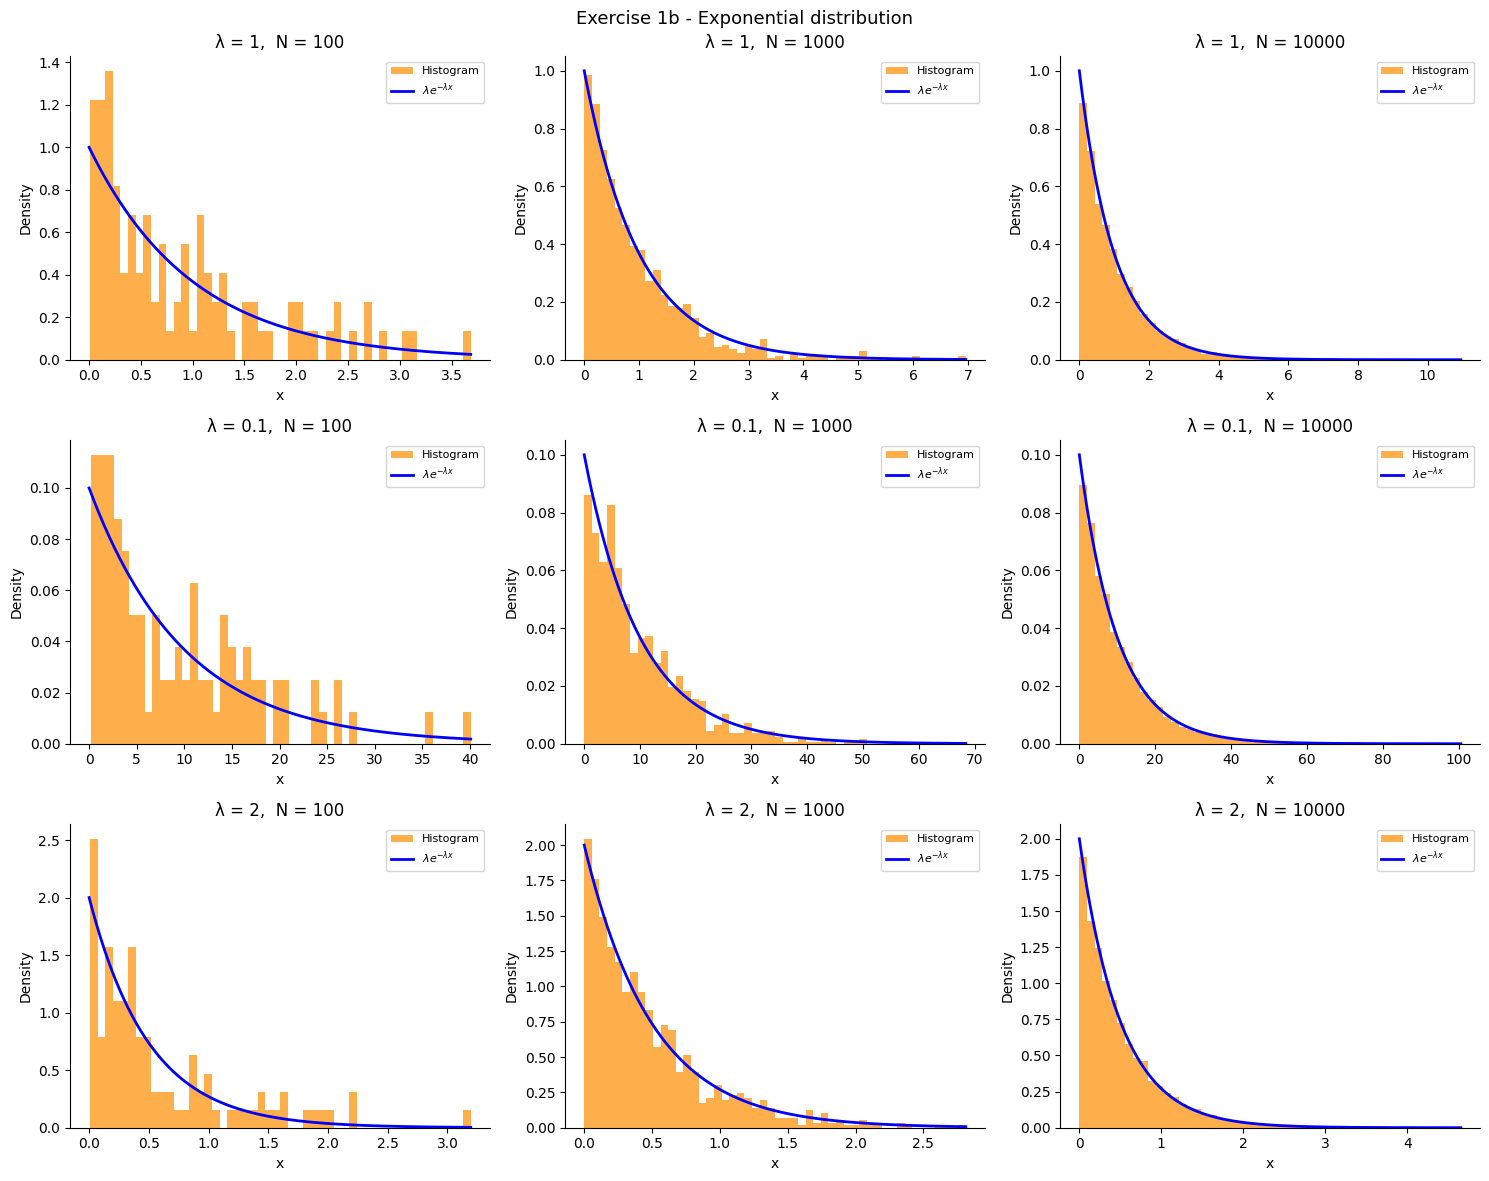

Observation: As N increases, the normalised histogram converges more closely to the theoretical pdf, with less noise in each bin.


In [28]:
lambda_values = [1, 0.1, 2]
N_values = [100, 1000, 10000]

exp_samples = {}   # storing these exponential samples  for later use in Ex 1d

fig, axes = plt.subplots(len(lambda_values), len(N_values),figsize=(15, 12))
fig.suptitle('Exercise 1b - Exponential distribution', fontsize=13)

for i, lam in enumerate(lambda_values):
    for j, N in enumerate(N_values):
        y = RNG.random(N)
        x = -(1 / lam) * np.log(1 - y)   # inverse CDF of exponential

        if lam == 1:
            exp_samples[N] = x            # save only the λ=1 samples for later

        ax = axes[i][j]
        ax.hist(x, bins=BINS, density=True, color='darkorange', alpha=0.7, label='Histogram')

        x_plot = np.linspace(0, x.max(), 300)
        ax.plot(x_plot, lam * np.exp(-lam * x_plot), 'b-', lw=2, label=r'$\lambda e^{-\lambda x}$')

        ax.set_title(f'λ = {lam},  N = {N}')
        ax.set_xlabel('x')
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Observation: As N increases, the normalised histogram converges more closely to the theoretical pdf, with less noise in each bin.")

### Exercise 1d - Sampling the standard normal distribution

Using the polar decomposition:
- $R \sim Exp(λ=1)$  →  samples from Exercise 1b (λ=1)
- $Θ \sim Uniform[0, 2π]$   →  samples from Exercise 1a

Then $X = √(2R) cos(Θ)$,  $Y = √(2R) sin(Θ)$  are i.i.d. standard normal.

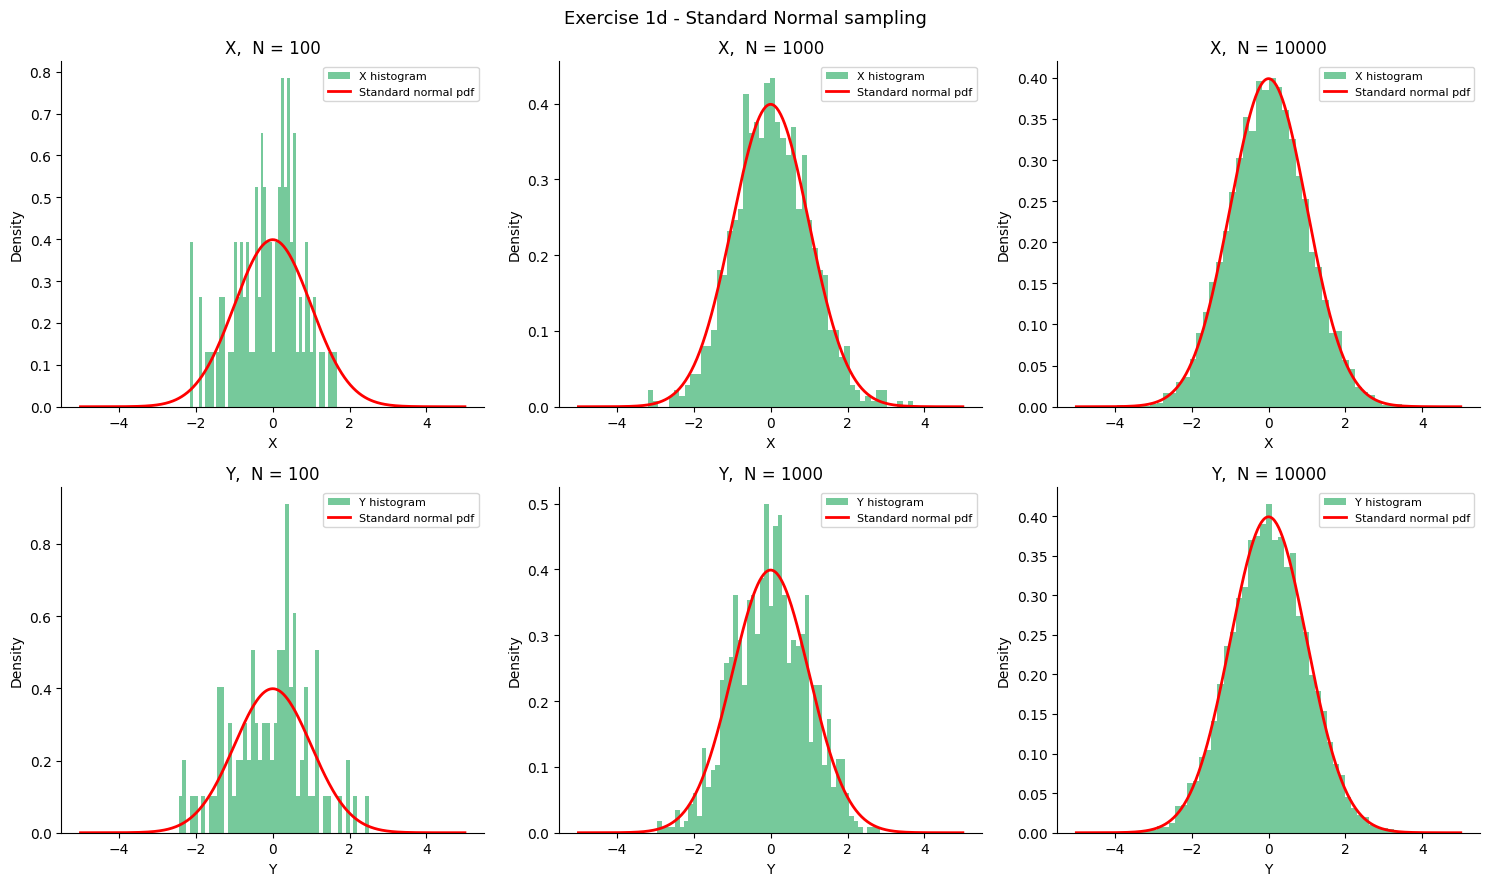

In [29]:
normal_samples = {}   # storring for later use

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Exercise 1d - Standard Normal sampling', fontsize=13)

x_plot = np.linspace(-5, 5, 400)
pdf_std = norm.pdf(x_plot, 0, 1)

for col, N in enumerate(N_values):
    theta = uniform_samples[N]        # Θ ~ Uniform[0, 2π], from 1(a)
    rho   = exp_samples[N]            # R ~ Exp(1), from 1(b)

    X = np.sqrt(2 * rho) * np.cos(theta)
    Y = np.sqrt(2 * rho) * np.sin(theta)
    normal_samples[N] = (X, Y)

    for row, (samples, label) in enumerate([(X, 'X'), (Y, 'Y')]):
        ax = axes[row][col]
        ax.hist(samples, bins=BINS, density=True, color='mediumseagreen', alpha=0.7, label=f'{label} histogram')
        ax.plot(x_plot, pdf_std, 'r-', lw=2, label='Standard normal pdf')
        ax.set_title(f'{label},  N = {N}')
        ax.set_xlabel(label)
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Exercise 1e - Normal distributions with custom mean and variance

Using the transformations:
$X₁ = μ₁ + σ₁ √(2R) cos(Θ)$,   $X₂ = μ₂ + σ₂ √(2R) sin(Θ)$

with $μ₁=1, μ₂=−1, σ₁=2, σ₂=0.5$ and $N=10000$.

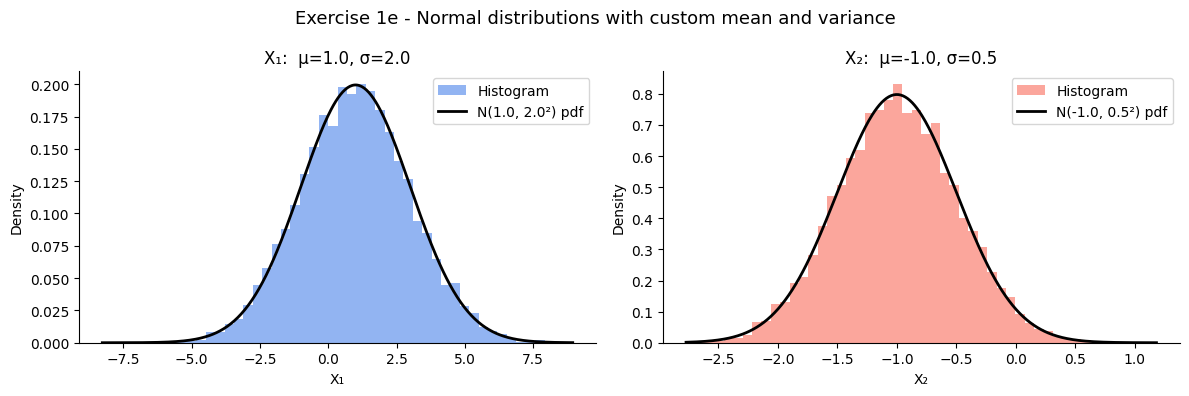

In [30]:
N = 10000
mu1, mu2 = 1.0, -1.0
sig1, sig2 = 2.0, 0.5

theta = uniform_samples[N] # from ex 1a
rho   = exp_samples[N] # from ex 1b

X1 = mu1 + sig1 * np.sqrt(2 * rho) * np.cos(theta)
X2 = mu2 + sig2 * np.sqrt(2 * rho) * np.sin(theta)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Exercise 1e - Normal distributions with custom mean and variance', fontsize=13)

params = [(X1, mu1, sig1, 'X₁', 'cornflowerblue'),
          (X2, mu2, sig2, 'X₂', 'salmon')]

for ax, (samples, mu, sig, label, color) in zip(axes, params):
    ax.hist(samples, bins=BINS, density=True, color=color, alpha=0.7, label='Histogram')
    x_plot = np.linspace(samples.min(), samples.max(), 400)
    ax.plot(x_plot, norm.pdf(x_plot, mu, sig), 'k-', lw=2, label=f'N({mu}, {sig}²) pdf')
    ax.set_title(f'{label}:  μ={mu}, σ={sig}')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

### Exercise 1g - Correlated normal random variables 

We form $X' = aX + bY$,  $Y' = cX + dY$  with the given matrix, starting from $N(0,1)$ samples.

Pearson correlation coefficient ρ(X', Y') = 0.5121


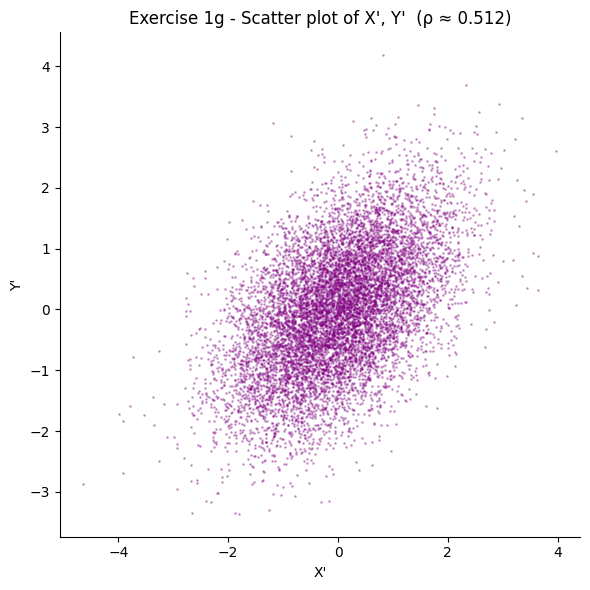

A clear positive correlation is visible in the scatter plot, consistent with the non-zero Pearson coefficient.


In [36]:
N = 10000
X, Y = normal_samples[N]   # i.i.d. N(0,1)

# Transformation matrix
a, b = 1,          0
c, d = 1/2, np.sqrt(3)/2

X_prime = a * X + b * Y
Y_prime = c * X + d * Y

# Pearson correlation coefficient
pearson = np.corrcoef(X_prime, Y_prime)[0, 1]
print(f"Pearson correlation coefficient ρ(X', Y') = {pearson:.4f}")
      

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X_prime, Y_prime, s=1, alpha=0.3, color='purple')
ax.set_xlabel("X'")
ax.set_ylabel("Y'")
ax.set_title(f"Exercise 1g - Scatter plot of X', Y'  (ρ ≈ {pearson:.3f})")

plt.tight_layout()
plt.show()

print("A clear positive correlation is visible in the scatter plot, consistent with the non-zero Pearson coefficient.")

---
## Section 2 - Brownian Motion

### Exercise 2a - Simulating the Wiener process (R=10 realisations)

We partition $[0, 1]$ into $N=1000$ equal steps and simulate $R=10$ paths.

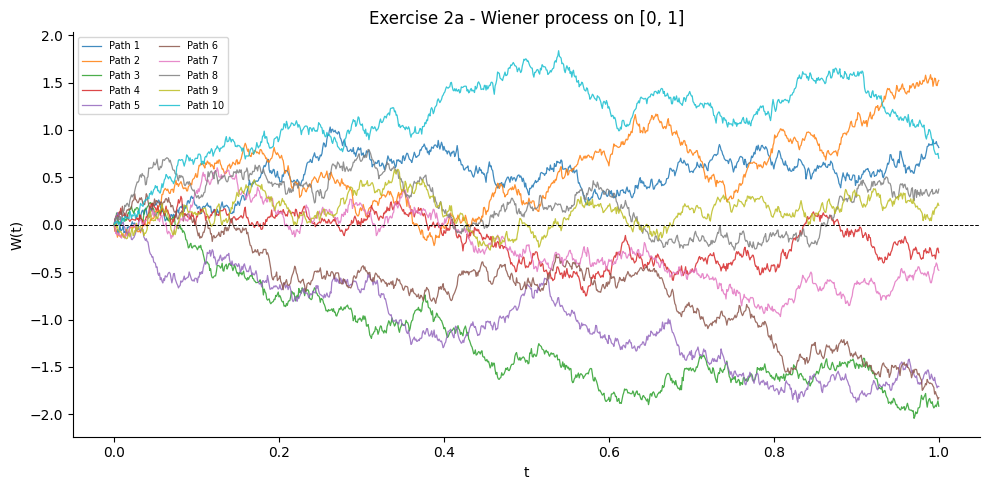

In [32]:
def simulate_wiener(T=1.0, N=1000, R=10, rng=None):
    """Simulate R independent Wiener process paths on [0,T] with N steps.
    Returns t (shape N+1,) and W (shape R, N+1)."""
    if rng is None:
        rng = np.random.default_rng()
    eps = T / N
    increments = rng.standard_normal((R, N)) * np.sqrt(eps)  # shape (R, N)
    W = np.zeros((R, N + 1))
    W[:, 1:] = np.cumsum(increments, axis=1)
    t = np.linspace(0, T, N + 1)
    return t, W


T, N_bm = 1.0, 1000
R = 10
t, W = simulate_wiener(T=T, N=N_bm, R=R, rng=RNG)

cmap = plt.cm.tab10
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(R):
    ax.plot(t, W[i], lw=0.9, color=cmap(i / R), alpha=0.85, label=f'Path {i+1}')
ax.axhline(0, color='black', lw=0.7, ls='--')
ax.set_xlabel('t')
ax.set_ylabel('W(t)')
ax.set_title('Exercise 2a - Wiener process on [0, 1]')
ax.legend(loc='upper left', fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

### Exercise 2b - Distribution of $W(t)$ at fixed time instants

For each $R \in \{100, 1000, 10000\}$ and $N=10000$ we record $W$ at $t = 0.2, 0.4, 0.6, 0.8, 1.0$
and verify that the values follow $N(0, t)$.

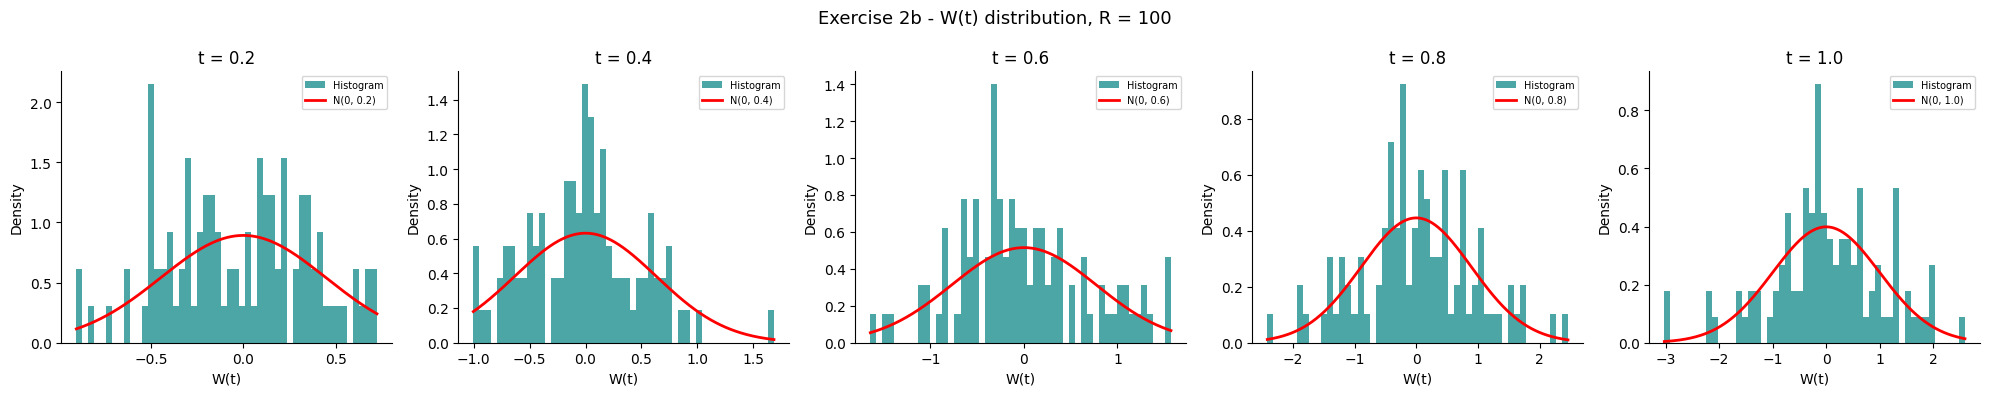

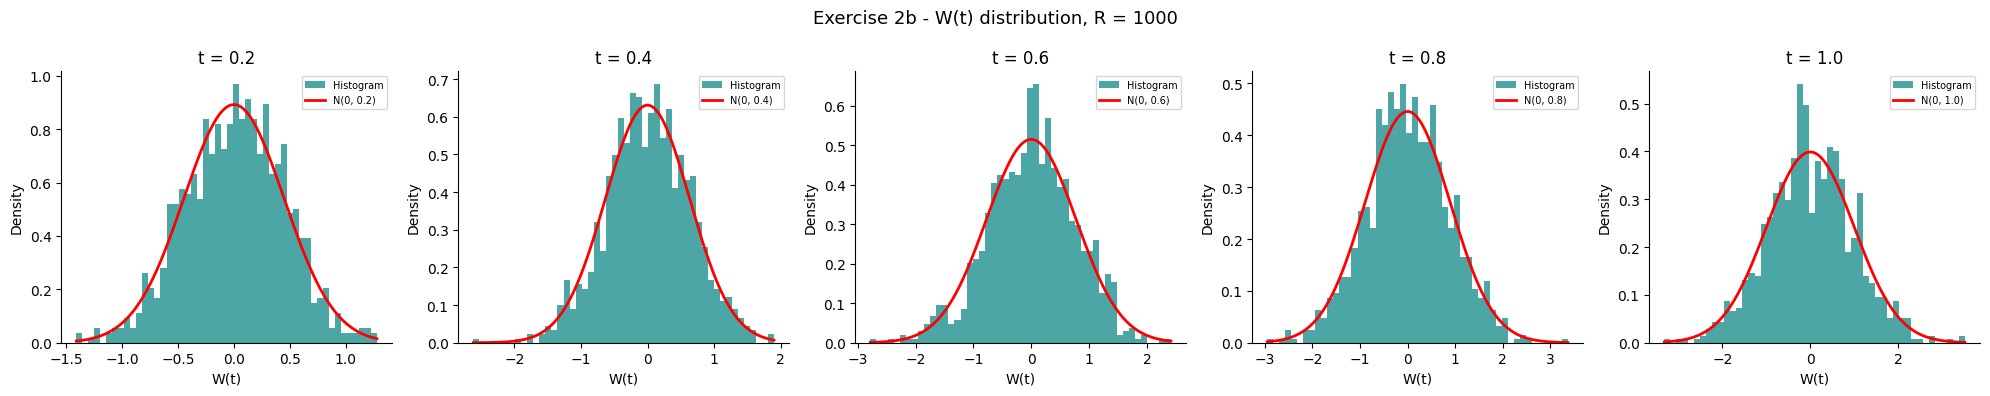

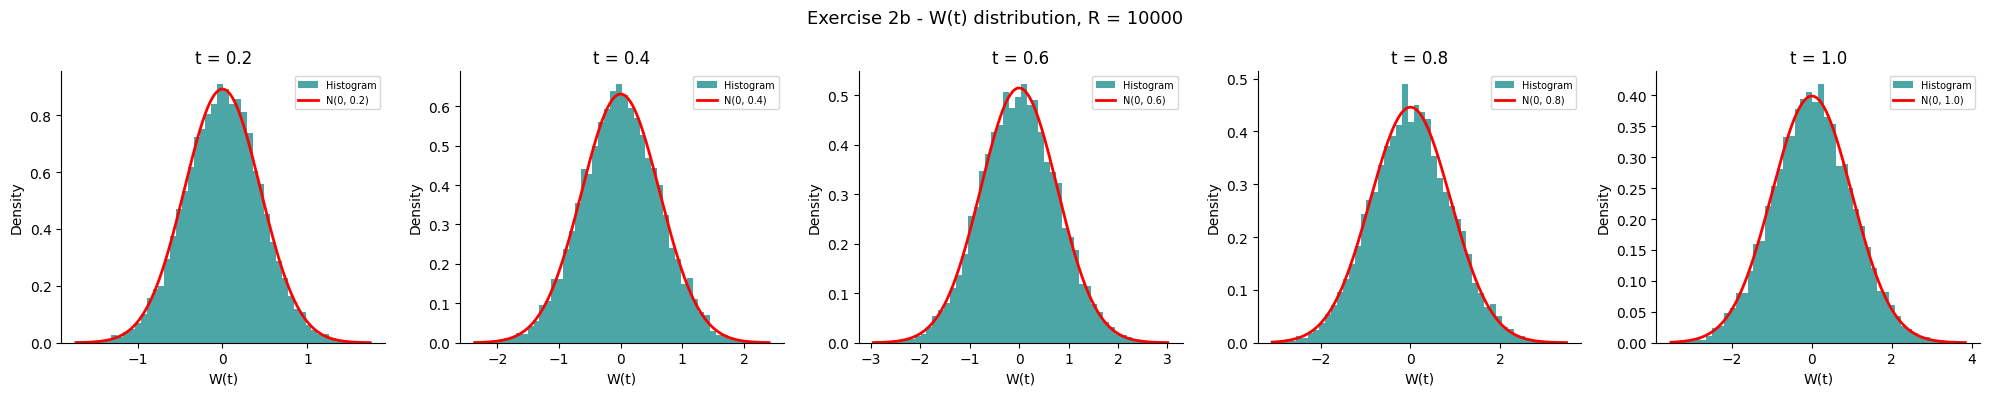

Observation: As R increases, the histograms match the theoretical normal distributions more and more closely.


In [33]:
T, N_bm = 1.0, 10000
time_instants = [0.2, 0.4, 0.6, 0.8, 1.0]
R_values_2b = [100, 1000, 10000]

#mapping each time instant to its index in the time grid
t_full = np.linspace(0, T, N_bm + 1)
time_indices = [np.argmin(np.abs(t_full - t_val)) for t_val in time_instants]

for R in R_values_2b:
    _, W = simulate_wiener(T=T, N=N_bm, R=R, rng=RNG)

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle(f'Exercise 2b - W(t) distribution, R = {R}', fontsize=13)

    for ax, t_val, idx in zip(axes, time_instants, time_indices):
        values = W[:, idx]
        ax.hist(values, bins=BINS, density=True, color='teal', alpha=0.7, label='Histogram')
        x_plot = np.linspace(values.min(), values.max(), 300)
        ax.plot(x_plot, norm.pdf(x_plot, 0, np.sqrt(t_val)), 'r-', lw=2, label=f'N(0, {t_val})')
        ax.set_title(f't = {t_val}')
        ax.set_xlabel('W(t)')
        ax.set_ylabel('Density')
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

print("Observation: As R increases, the histograms match the theoretical normal distributions more and more closely.")

### Exercise 2c - Quadratic variation of the Wiener process

$[W,W](T) = \sum (W(t_i) − W(t_{i-1}))^2$

Theoretically $[W,W](1) = 1$ almost surely.  We study the empirical distribution for R=100 and R=1000.

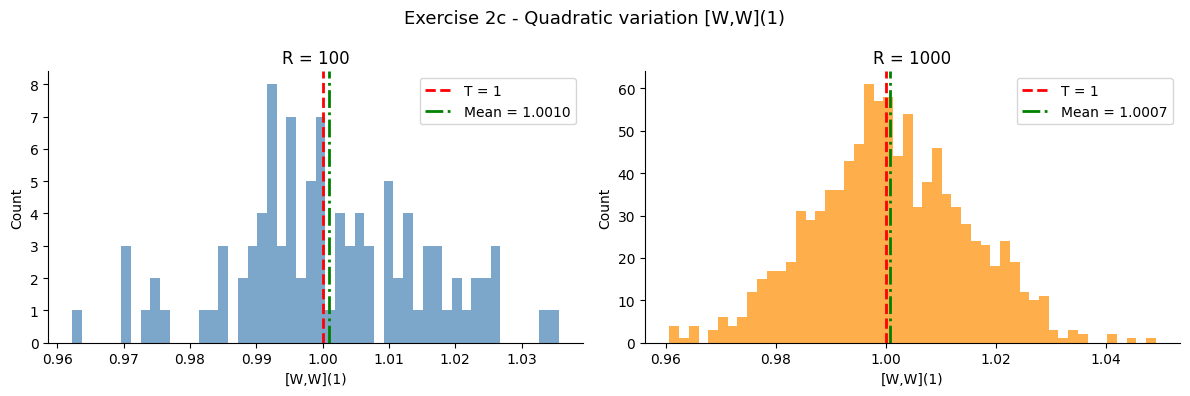

R=100  - mean QV: 1.00101,  std: 0.01468
R=1000 - mean QV: 1.00073,  std: 0.01399

Both histograms centre on T=1.  With R=1000 the spread is still present (QV = T holds only almost surely, not path-by-path).


In [34]:
T, N_bm = 1.0, 10000
eps = T / N_bm

#store R=100 increments for Exer 2d
R_100 = 100
increments_100 = RNG.standard_normal((R_100, N_bm)) * np.sqrt(eps)
W_100 = np.zeros((R_100, N_bm + 1))
W_100[:, 1:] = np.cumsum(increments_100, axis=1)

qv_100 = np.sum(increments_100 ** 2, axis=1)   # quadratic variation per path

# R = 1000
R_1000 = 1000
increments_1000 = RNG.standard_normal((R_1000, N_bm)) * np.sqrt(eps)
qv_1000 = np.sum(increments_1000 ** 2, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Exercise 2c - Quadratic variation [W,W](1)', fontsize=13)

for ax, qv, R, color in zip(axes,[qv_100, qv_1000], [100, 1000],['steelblue', 'darkorange']):
    ax.hist(qv, bins=BINS, color=color, alpha=0.7)
    ax.axvline(1.0, color='red', lw=2, ls='--', label='T = 1')
    ax.axvline(qv.mean(), color='green', lw=2, ls='-.', label=f'Mean = {qv.mean():.4f}')
    ax.set_title(f'R = {R}')
    ax.set_xlabel('[W,W](1)')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

print(f"R=100  - mean QV: {qv_100.mean():.5f},  std: {qv_100.std():.5f}")
print(f"R=1000 - mean QV: {qv_1000.mean():.5f},  std: {qv_1000.std():.5f}")
print("\nBoth histograms centre on T=1.  With R=1000 the spread is still present "
      "(QV = T holds only almost surely, not path-by-path).")

### Exercise 2d - Running maximum (maximum-to-date) process

$M(t) = max_{0 \leq s \leq t} W(s)$

We plot both $W(t)$ and $M(t)$ for $5$ randomly chosen paths from the $R=100$ realisations.

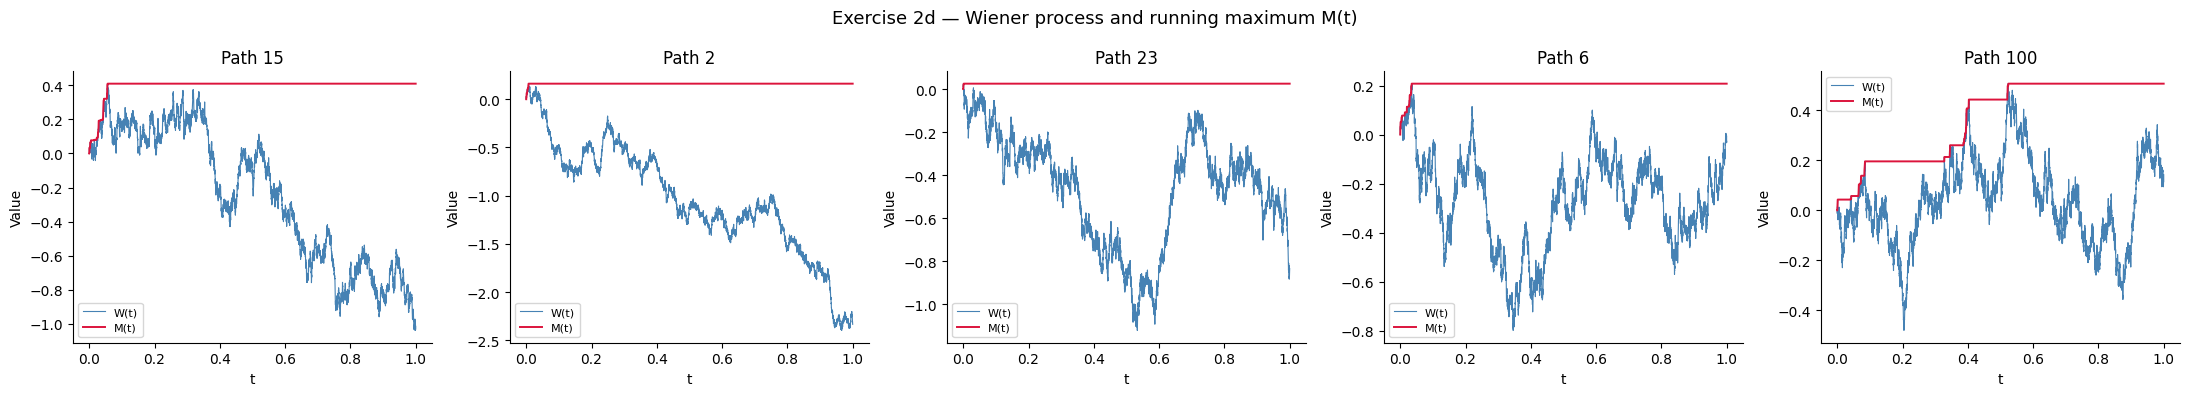

M(t) is non-decreasing by definition; it stays flat whenever W(t) is below its current maximum and jumps up whenever W(t) sets a new high.


In [35]:
t_full = np.linspace(0, T, N_bm + 1)

#Computes running maximum for each of the 100 paths
M_100 = np.maximum.accumulate(W_100, axis=1)   # shape (100, N+1)

chosen = [14, 1, 22, 5, 99]   # 5  paths

fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=False)
fig.suptitle('Exercise 2d — Wiener process and running maximum M(t)', fontsize=13)

for ax, idx in zip(axes, chosen):
    ax.plot(t_full, W_100[idx], color='steelblue', lw=0.8, label='W(t)')
    ax.plot(t_full, M_100[idx], color='crimson',  lw=1.4, label='M(t)')
    ax.set_title(f'Path {idx + 1}')
    ax.set_xlabel('t')
    ax.set_ylabel('Value')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("M(t) is non-decreasing by definition; it stays flat whenever W(t) is below its current maximum and jumps up whenever W(t) sets a new high.")